In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from transformers import SwinForImageClassification, AutoImageProcessor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from tqdm import tqdm
from PIL import Image

c:\Users\Shubhankar\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Path to dataset (all classes in subfolders)
data_dir = r"C:\Users\Shubhankar\Downloads\archive (3)\Alzheimer_MRI_4_classes_dataset"

In [4]:
# Load processor and define transform
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

In [5]:
# Load full dataset
full_dataset = ImageFolder(data_dir, transform=transform)
class_names = full_dataset.classes
print("Classes:", class_names)

Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [6]:
# Split into train (70%), val (20%), test (10%)
from torch.utils.data import DataLoader, random_split
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [7]:
model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=len(class_names),
    ignore_mismatched_sizes=True  # <== this fixes the error
).to(device)


Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [9]:
# Initialize metric lists
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

In [10]:
import torch
print(torch.cuda.is_available())            # Should return True
print(torch.cuda.get_device_name(0))        # Should print your GPU name

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [11]:
# Training loop
for epoch in range(100):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/100"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    acc = total_correct / total_samples
    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}, Accuracy = {acc:.4f}")

Epoch 1/100: 100%|██████████| 280/280 [01:12<00:00,  3.87it/s]


Epoch 1: Loss = 268.6937, Accuracy = 0.5377


Epoch 2/100: 100%|██████████| 280/280 [01:12<00:00,  3.84it/s]


Epoch 2: Loss = 219.9505, Accuracy = 0.6433


Epoch 3/100: 100%|██████████| 280/280 [01:11<00:00,  3.90it/s]


...

Epoch 98: Loss = 0.1631, Accuracy = 1.0000


Epoch 99/100: 100%|██████████| 280/280 [01:12<00:00,  3.89it/s]


Epoch 99: Loss = 2.6589, Accuracy = 0.9975


Epoch 100/100: 100%|██████████| 280/280 [01:11<00:00,  3.90it/s]

Epoch 100: Loss = 4.2853, Accuracy = 0.9953


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval() 
val_preds = []
val_labels = []

with torch.no_grad():
    for val_images, val_targets in val_loader:
        val_images = val_images.to(device)
        val_targets = val_targets.to(device)

        val_outputs = model(val_images).logits
        _, predicted = torch.max(val_outputs, 1)

        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(val_targets.cpu().numpy())

# 🔍 Calculate and print metrics
val_accuracy = accuracy_score(val_labels, val_preds)
print(f"\n✅ Final Validation Accuracy: {val_accuracy * 100:.2f}%")

print("\n🧾 Classification Report:")
print(classification_report(val_labels, val_preds, target_names=class_names))

print("\n🌀 Confusion Matrix:")
print(confusion_matrix(val_labels, val_preds))



✅ Final Validation Accuracy: 99.22%

🧾 Classification Report:
                  precision    recall  f1-score   support

    MildDemented       1.00      0.98      0.99       186
ModerateDemented       1.00      1.00      1.00        15
     NonDemented       0.99      1.00      0.99       627
VeryMildDemented       0.99      0.99      0.99       452

        accuracy                           0.99      1280
       macro avg       1.00      0.99      0.99      1280
    weighted avg       0.99      0.99      0.99      1280


🌀 Confusion Matrix:
[[183   0   0   3]
 [  0  15   0   0]
 [  0   0 626   1]
 [  0   0   6 446]]


In [19]:
    # Save training metrics
train_losses.append(total_loss / len(train_loader))
train_accuracies.append(acc)

    # Validate
model.eval()
val_loss, val_correct, val_total = 0.0, 0, 0
with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            val_outputs = model(val_images).logits
            val_loss += criterion(val_outputs, val_labels).item()
            _, val_preds = torch.max(val_outputs, 1)
            val_correct += (val_preds == val_labels).sum().item()
            val_total += val_labels.size(0)

val_acc = val_correct / val_total
val_losses.append(val_loss / len(val_loader))
val_accuracies.append(val_acc)
print(f"✅ Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Train Acc={acc:.4f}, Val Loss={val_losses[-1]:.4f}, Val Acc={val_acc:.4f}")


✅ Epoch 100: Train Loss=0.0153, Train Acc=0.9953, Val Loss=0.0404, Val Acc=0.9922


C:\Users\Shubhankar\AppData\Local\Temp\ipykernel_22512\3438318786.py:30: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\Shubhankar\AppData\Local\Temp\ipykernel_22512\3438318786.py:30: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()


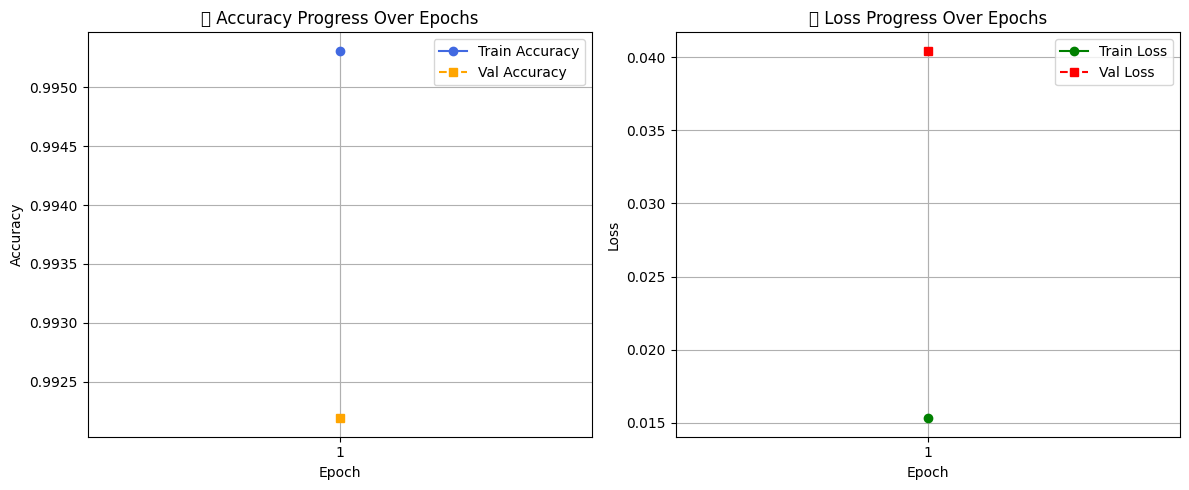

In [22]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_accuracies) + 1))

# Progress graph for Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, marker='o', linestyle='-', color='royalblue', label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='s', linestyle='--', color='orange', label='Val Accuracy')
plt.fill_between(epochs, train_accuracies, val_accuracies, color='lightgray', alpha=0.3)
plt.title('📈 Accuracy Progress Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

# Progress graph for Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, marker='o', linestyle='-', color='green', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', linestyle='--', color='red', label='Val Loss')
plt.fill_between(epochs, train_losses, val_losses, color='lightgray', alpha=0.3)
plt.title('📉 Loss Progress Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [23]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).logits
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
    return np.array(y_true), np.array(y_pred)

In [24]:
y_true, y_pred = evaluate(model, test_loader)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
                  precision    recall  f1-score   support

    MildDemented       1.00      0.98      0.99        93
ModerateDemented       1.00      1.00      1.00         4
     NonDemented       0.99      0.99      0.99       324
VeryMildDemented       0.98      0.99      0.98       219

        accuracy                           0.99       640
       macro avg       0.99      0.99      0.99       640
    weighted avg       0.99      0.99      0.99       640



In [26]:
torch.save(model.state_dict(), "swin_alzheimer_model.pth")


🖼️ Image: moderateDem6.jpg
✅ Predicted Class: ModerateDemented
📊 Confidence: 100.00%


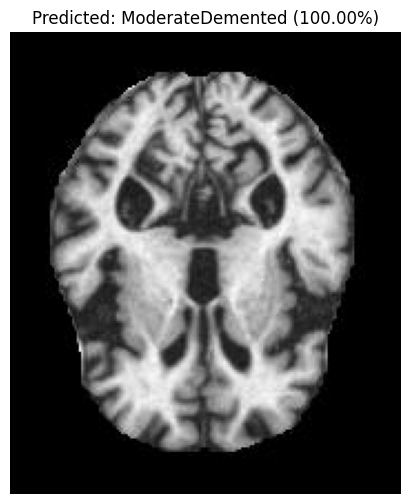

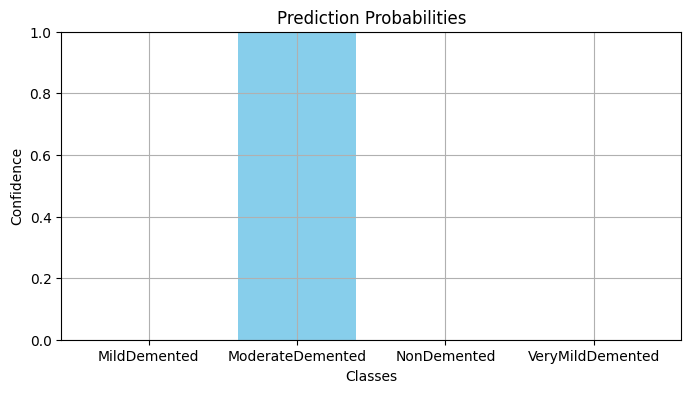

In [28]:
import torch.nn.functional as F
image_path = r"C:\Users\Shubhankar\Downloads\Alzheimers disease dataset\Alzheimers disease dataset\Alzheimer's dataset\OriginalDataset\ModerateDemented\moderateDem6.jpg"  # Replace with your test image path
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs).logits
    probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_class_idx = probs.argmax()
    pred_class = class_names[pred_class_idx]
    confidence = probs[pred_class_idx]

print(f"🖼️ Image: {os.path.basename(image_path)}")
print(f"✅ Predicted Class: {pred_class}")
print(f"📊 Confidence: {confidence*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted: {pred_class} ({confidence*100:.2f}%)")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(class_names, probs, color='skyblue')
plt.title("Prediction Probabilities")
plt.xlabel("Classes")
plt.ylabel("Confidence")
plt.ylim([0, 1])
plt.grid(True)
plt.show()


🖼️ Image: verymildDem987.jpg
✅ Predicted Class: VeryMildDemented
📊 Confidence: 100.00%


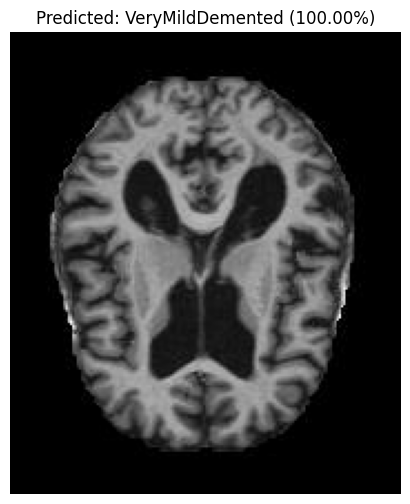

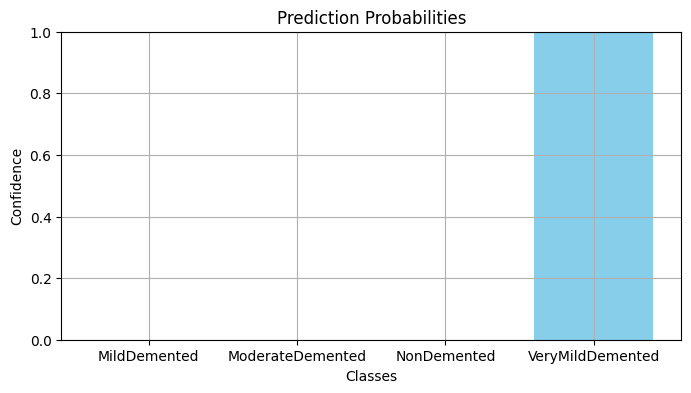

In [29]:
image_path = r"C:\Users\Shubhankar\Downloads\Alzheimers disease dataset\Alzheimers disease dataset\Alzheimer's dataset\OriginalDataset\VeryMildDemented\verymildDem987.jpg"  # Replace with your test image path
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs).logits
    probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_class_idx = probs.argmax()
    pred_class = class_names[pred_class_idx]
    confidence = probs[pred_class_idx]

print(f"🖼️ Image: {os.path.basename(image_path)}")
print(f"✅ Predicted Class: {pred_class}")
print(f"📊 Confidence: {confidence*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted: {pred_class} ({confidence*100:.2f}%)")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(class_names, probs, color='skyblue')
plt.title("Prediction Probabilities")
plt.xlabel("Classes")
plt.ylabel("Confidence")
plt.ylim([0, 1])
plt.grid(True)
plt.show()


🖼️ Image: 32.jpg
✅ Predicted Class: ModerateDemented
📊 Confidence: 92.66%


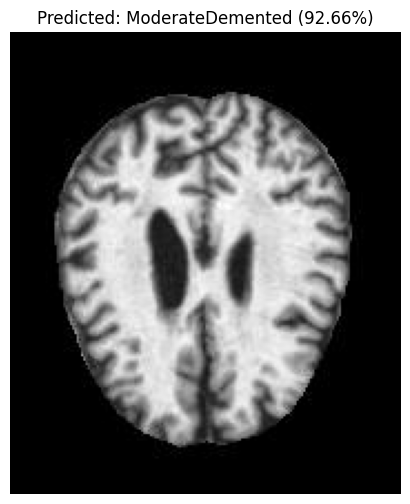

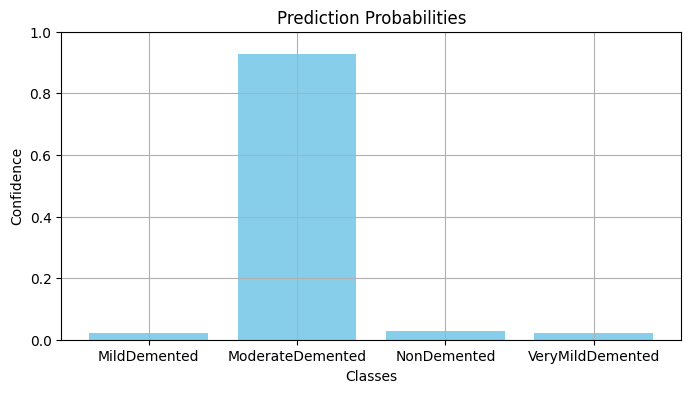

In [30]:
image_path = r"C:\Users\Shubhankar\Downloads\Alzheimers disease dataset\Alzheimers disease dataset\Alzheimer's dataset\OriginalDataset\ModerateDemented\32.jpg"  # Replace with your test image path
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs).logits
    probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_class_idx = probs.argmax()
    pred_class = class_names[pred_class_idx]
    confidence = probs[pred_class_idx]

print(f"🖼️ Image: {os.path.basename(image_path)}")
print(f"✅ Predicted Class: {pred_class}")
print(f"📊 Confidence: {confidence*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted: {pred_class} ({confidence*100:.2f}%)")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(class_names, probs, color='skyblue')
plt.title("Prediction Probabilities")
plt.xlabel("Classes")
plt.ylabel("Confidence")
plt.ylim([0, 1])
plt.grid(True)
plt.show()


🖼️ Image: 29 (10).jpg
✅ Predicted Class: MildDemented
📊 Confidence: 100.00%


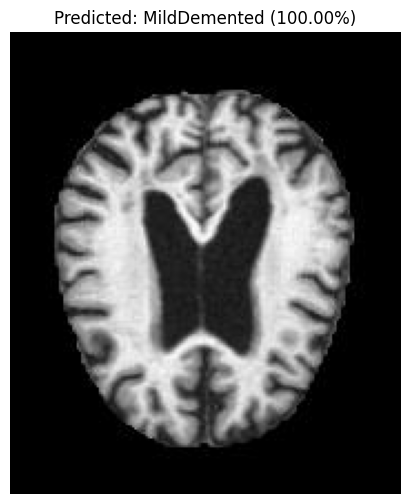

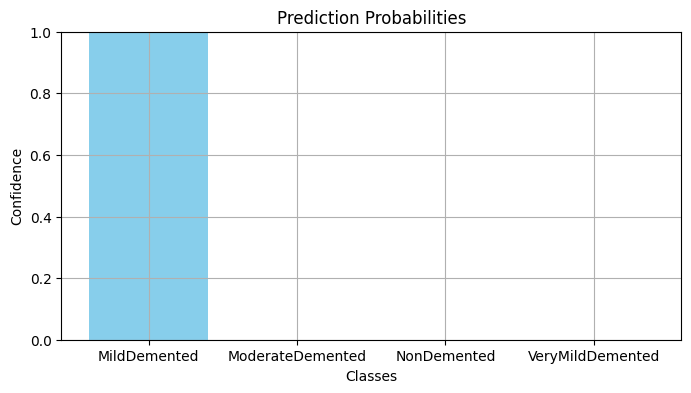

In [31]:
image_path =r"C:\Users\Shubhankar\Downloads\Alzheimers disease dataset\Alzheimers disease dataset\Alzheimer's dataset\OriginalDataset\MildDemented\29 (10).jpg"  # Replace with your test image path
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs).logits
    probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_class_idx = probs.argmax()
    pred_class = class_names[pred_class_idx]
    confidence = probs[pred_class_idx]

print(f"🖼️ Image: {os.path.basename(image_path)}")
print(f"✅ Predicted Class: {pred_class}")
print(f"📊 Confidence: {confidence*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted: {pred_class} ({confidence*100:.2f}%)")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(class_names, probs, color='skyblue')
plt.title("Prediction Probabilities")
plt.xlabel("Classes")
plt.ylabel("Confidence")
plt.ylim([0, 1])
plt.grid(True)
plt.show()
